# Galactic Astrophysics Notebook

## Part 2: Classification of galaxy morphology

The Galaxy Zoo Project 2 classfied around 200,000 galaxy images obtained from the Sloan Digital Sky Survey (SDSS), DR7 and other similar surveys. The images are classified into 37 categories following a set of 11 questions with the help of the public (citizen scientists).

For these tasks, we will use a subset of the Galaxy Zoo dataset consisting of 10,000 galaxy images in the training dataset and 2000 images for the test dataset.

Please download the main folder from here: https://drive.google.com/file/d/1IZm7C4KbJnAQfxBwkiXLAKf5P-CbR0-x/view?usp=sharing

(Note that this is almost 200MB)

These are the modules that you will need:

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
print(torch.__version__)

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

2.7.0


Now you shold set up the path to your data, this depends on where you saved it. 
Please set a path for 

main folder (galaxy-zoo-small)

The training images (images_train_small)

The labels (train_labels_small.csv)

Then save the labels in a dataframe using pandas. 

In [40]:
main_dir = "galaxy-zoo-small"
train_dir = "galaxy-zoo-small\images_train_small"
test_dir = "galaxy-zoo-small\images_test_small"
train_labels_dir = "galaxy-zoo-small\\train_labels_small.csv"
test_labels_dir = "galaxy-zoo-small\\test_labels_small.csv"

# os.listdir()

labels_df = pd.read_csv(train_labels_dir).set_index("GalaxyID")

It is a good idea to confirm the number of images in the dataset to check it is what you expect.

I have started this with the first line, please continue to count them. 

In [41]:
# Get a list of all image files
image_files = [f for f in os.listdir(train_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]


Now we need to label each galaxy so that we can train the CNN with data that it knows the answer to

The galaxies in galaxy zoo do not have strict labels, they have probabilites. You can read about this here: 

www.kaggle.com/competitions/galaxy-zoo-the-galaxy-challenge/overview/the-galaxy-zoo-decision-tree

Print out the first few rows of the dataframe containing the probabilies:


In [42]:
labels_df = pd.read_csv(train_labels_dir)
print(labels_df)

      GalaxyID   Class1.1   Class1.2   Class1.3   Class2.1      Class2.2     \
0       100023   0.327001   0.663777   0.009222      0.031178      0.632599   
1       100090   0.933839   0.000000   0.066161      0.000000      0.000000   
2       100322   0.091987   0.908013   0.000000      0.816806      0.091207   
3       100380   0.030000   0.970000   0.000000      0.043650      0.926350   
4       100867   0.806776   0.143003   0.050220      0.000000      0.143003   
...        ...        ...        ...        ...           ...           ...   
9995    999540   0.634047   0.304343   0.061610      0.000000      0.304343   
9996    999622   0.522898   0.474120   0.002982      0.189648      0.284472   
9997    999731   0.621364   0.378636   0.000000      0.159003      0.219633   
9998    999900   0.460239   0.511396   0.028365      0.109439      0.401957   
9999    999936   0.545443   0.454557   0.000000      0.056820      0.397737   

       Class3.1      Class3.2      Class4.1      Cl

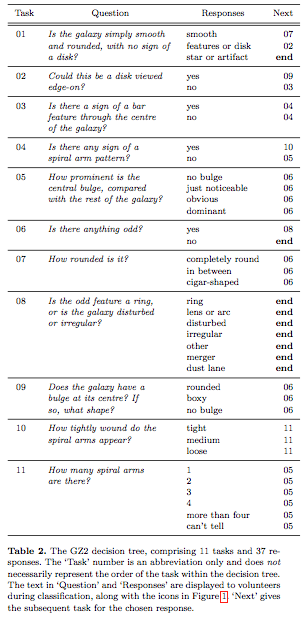

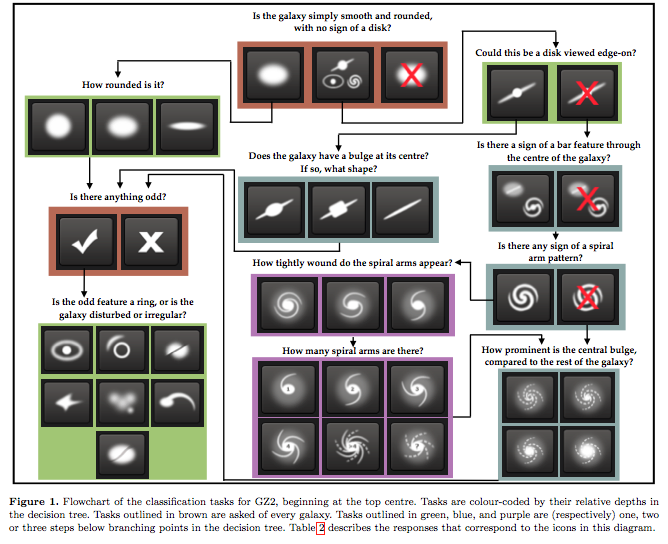

In [43]:
from IPython.display import Image, display
display(Image(filename='figure1.png', width=300))
display(Image(filename='table2.png', width=600))

You can see how the classes match up to the questions in the table (and so the images in the first figure here).

For your first attempt as classification, lets take class 1.2 (corresponding to task 01 'features or disk' and the middle image in the first section of the flow chart) to be sprial. For elliptical, lets choose class 1.1 (corresponding to task 01 'smooth' and the left image in the first section of the flow chart).

To narrow down the images, choose a probabiltiy of above 0.8 for each class from the dataframe, then we will give this the label 'spiral' (1) or 'elliptical' (2).


In [44]:
print(labels_df)
# Spiral if Class1.2 > 0.8
spirals = labels_df[labels_df[" Class1.2"] > 0.8].copy()
spirals["label"] = 1

# Elliptical if Class1.1 > 0.8
ellipticals = labels_df[labels_df[" Class1.1"] > 0.8].copy()
ellipticals["label"] = 0



      GalaxyID   Class1.1   Class1.2   Class1.3   Class2.1      Class2.2     \
0       100023   0.327001   0.663777   0.009222      0.031178      0.632599   
1       100090   0.933839   0.000000   0.066161      0.000000      0.000000   
2       100322   0.091987   0.908013   0.000000      0.816806      0.091207   
3       100380   0.030000   0.970000   0.000000      0.043650      0.926350   
4       100867   0.806776   0.143003   0.050220      0.000000      0.143003   
...        ...        ...        ...        ...           ...           ...   
9995    999540   0.634047   0.304343   0.061610      0.000000      0.304343   
9996    999622   0.522898   0.474120   0.002982      0.189648      0.284472   
9997    999731   0.621364   0.378636   0.000000      0.159003      0.219633   
9998    999900   0.460239   0.511396   0.028365      0.109439      0.401957   
9999    999936   0.545443   0.454557   0.000000      0.056820      0.397737   

       Class3.1      Class3.2      Class4.1      Cl

Print out how many there of each

In [45]:
print("Number of spirals : ",len(spirals))
print("Number of ellipticals : ", len(ellipticals))


Number of spirals :  2615
Number of ellipticals :  1308


With CNNs it is important for the dataset to be balanced so that it can learn from each type of image. 
You should see from the numbers that you have just printed out that it is unbalanced. 

Choose a random sample of 500 from each type to save for training of the model (lets start small, you can increase this later if you want to). 

Hint, you can use pd.concat here (remember to ensure that it is random)

In [46]:
import random

In [47]:
spiral_sample = spirals.sample(500)
elliptical_sample = ellipticals.sample(500)

train_df = pd.concat([spiral_sample, elliptical_sample])
train_df = train_df.sample(frac=1).reset_index(drop=True)

print(train_df)

     GalaxyID   Class1.1   Class1.2   Class1.3   Class2.1      Class2.2     \
0      220802   0.010397   0.989603   0.000000      0.021771      0.967832   
1      338073   0.885969   0.100465   0.013566      0.000000      0.100465   
2      244192   0.804000   0.087000   0.109000      0.000000      0.087000   
3      156541   0.132575   0.867425   0.000000      0.283742      0.583683   
4      308801   0.813469   0.183448   0.003083      0.122360      0.061088   
..        ...        ...        ...        ...           ...           ...   
995    595008   0.000000   0.996000   0.004000      0.000000      0.996000   
996    503651   0.887832   0.112168   0.000000      0.000000      0.112168   
997    738704   0.142739   0.845754   0.011507      0.000000      0.845754   
998    325464   0.910820   0.070652   0.018528      0.000000      0.070652   
999    619204   0.847610   0.137538   0.014852      0.000000      0.137538   

      Class3.1      Class3.2      Class4.1      Class4.2     ..

Here is some code to show some of the images, you can explore this

['100023.jpg', '100090.jpg', '100322.jpg', '100380.jpg', '100867.jpg']
Example Spiral Galaxies:
994632
galaxy-zoo-small\images_train_small\994632.jpg
465166
galaxy-zoo-small\images_train_small\465166.jpg
861674
galaxy-zoo-small\images_train_small\861674.jpg
496237
galaxy-zoo-small\images_train_small\496237.jpg
772930
galaxy-zoo-small\images_train_small\772930.jpg


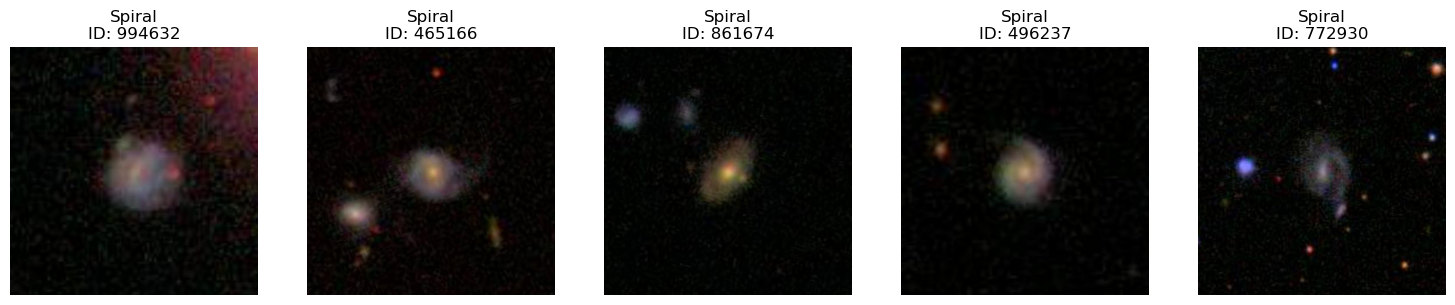

Example Elliptical Galaxies:
807466
galaxy-zoo-small\images_train_small\807466.jpg
829913
galaxy-zoo-small\images_train_small\829913.jpg
589030
galaxy-zoo-small\images_train_small\589030.jpg
619204
galaxy-zoo-small\images_train_small\619204.jpg
609696
galaxy-zoo-small\images_train_small\609696.jpg


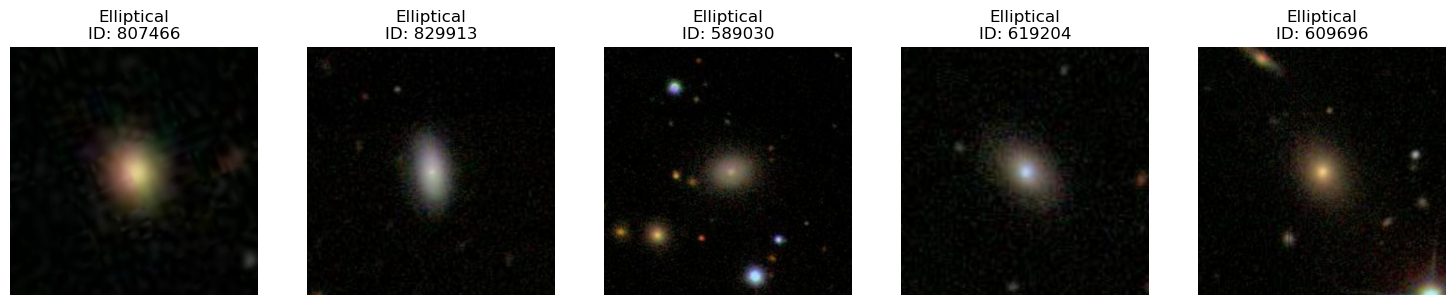

In [48]:
from PIL import Image as PILImage

def show_examples(df, images_dir, label_name, n=5):
    sample = df.sample(n, random_state=42)
    
    fig, axs = plt.subplots(1, n, figsize=(15, 3))
    
    for i, (_, row) in enumerate(sample.iterrows()):
        galaxy_id = int(row['GalaxyID'])
        print(galaxy_id)
        img_path = os.path.join(images_dir, f"{galaxy_id}.jpg")
        print(img_path)
        if not os.path.exists(img_path):
            print(f"Missing: {img_path}")
            axs[i].axis("off")
            continue
        img = PILImage.open(img_path)
        axs[i].imshow(img)
        axs[i].set_title(f"{label_name}\nID: {galaxy_id}")
        axs[i].axis("off")
    plt.tight_layout()
    plt.show()

print(os.listdir(train_dir)[:5])

print("Example Spiral Galaxies:")
show_examples(spirals, train_dir, "Spiral", n=5)

print("Example Elliptical Galaxies:")
show_examples(ellipticals, train_dir, "Elliptical", n=5)


### Preparing the data for the CNN
Now we start to prepare the data for the model and build it. I have provided most of the code here, you can read through it and come back to make changes later on to improve the accurayc of the classification.  

This part of the code tells PyTorch how to read each galaxy image, convert to grayscale, resize, and return with its label.

In [53]:
class GalaxyDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        galaxy_id = int(self.df.iloc[idx]['GalaxyID'])
        label = int(self.df.iloc[idx]["label"])
        img_path = os.path.join(self.img_dir, f"{galaxy_id}.jpg")
        img = PILImage.open(img_path).convert("L")  # grayscale
        if self.transform:
            img = self.transform(img)
        return img, label


Data transforms & loaders:

Resizes to 64×64 pixels, converts to tensor.
Splits dataset into 80% train, 20% test.
Loads in mini-batches of 32 galaxies.

In [54]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = GalaxyDataset(train_df, train_dir, transform=transform)

# Train/test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

CNN


Conv1 → finds edges.
Conv2 → finds bigger shapes.
FC1/FC2 → final decision: spiral or elliptical.

In [55]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 16 * 16, 64)
        self.fc2 = nn.Linear(64, 2)  # 2 classes

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 16 * 16)  # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training loop


For each epoch:
Show galaxy batch to CNN.
Compute error.
Update weights (learn).

In [59]:
for epoch in range(15):  # try 10–20 for better results
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.5910
Epoch 2, Loss: 0.5391
Epoch 3, Loss: 0.4797
Epoch 4, Loss: 0.4114
Epoch 5, Loss: 0.3691
Epoch 6, Loss: 0.3369
Epoch 7, Loss: 0.3210
Epoch 8, Loss: 0.2742
Epoch 9, Loss: 0.2570
Epoch 10, Loss: 0.2373
Epoch 11, Loss: 0.2347
Epoch 12, Loss: 0.2285
Epoch 13, Loss: 0.2118
Epoch 14, Loss: 0.2287
Epoch 15, Loss: 0.1841


Evaluation


Test accuracy.
Confusion matrix - this allows us to see per-class results - how well did the model do at classifiying?

Test Accuracy: 0.85


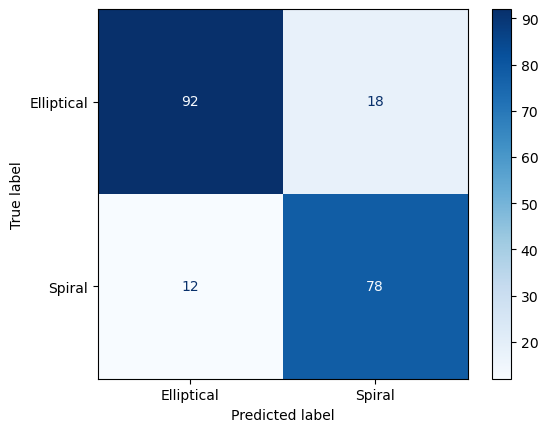

In [60]:
model.eval()
all_preds = []
all_labels = []
all_imgs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_imgs.extend(imgs.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_imgs = np.array(all_imgs)

# Accuracy
accuracy = (all_preds == all_labels).mean()
print("Test Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Elliptical", "Spiral"])
disp.plot(cmap="Blues", values_format="d")
plt.show()

Show examples


Top row = correct predictions.
Bottom row = mistakes (misclassifications).
You can see real galaxies and how the CNN did.

Correct examples: 170
Misclassified examples: 30


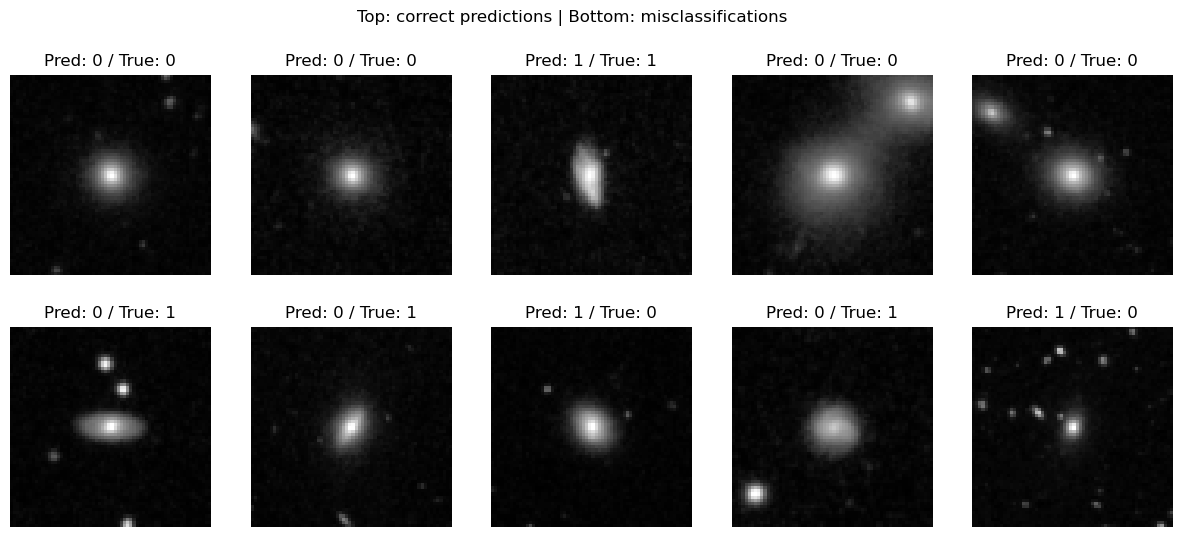

In [61]:
# -------------------
# 9. Show correct vs misclassified examples
# -------------------
correct_idx = np.where(all_preds == all_labels)[0]
incorrect_idx = np.where(all_preds != all_labels)[0]

print("Correct examples:", len(correct_idx))
print("Misclassified examples:", len(incorrect_idx))

num_show = 5
fig, axs = plt.subplots(2, num_show, figsize=(15, 6))

# Top row: correct
for i in range(num_show):
    if i < len(correct_idx):
        idx = correct_idx[i]
        axs[0, i].imshow(all_imgs[idx][0], cmap="gray")
        axs[0, i].set_title(f"Pred: {all_preds[idx]} / True: {all_labels[idx]}")
        axs[0, i].axis("off")

# Bottom row: misclassified
for i in range(num_show):
    if i < len(incorrect_idx):
        idx = incorrect_idx[i]
        axs[1, i].imshow(all_imgs[idx][0], cmap="gray")
        axs[1, i].set_title(f"Pred: {all_preds[idx]} / True: {all_labels[idx]}")
        axs[1, i].axis("off")

plt.suptitle("Top: correct predictions | Bottom: misclassifications")
plt.show()

The initial run should have a relativley low accuracy. 

To increase this you could try increasing the sample of galaxies used as input and the epoch size. 

A more important change would be to consider the classes. Look again at the flow chart of the decisions earlier in the notebook. Are there more clear examples of ellipticals and spirals we could use to label? Try changign the classes at the labelling stage. 